## 1. Import Required Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib

# Compatibility shim: matplotlib_inline expects RcParams._get in some versions.
if not hasattr(matplotlib.RcParams, "_get"):
    matplotlib.RcParams._get = matplotlib.RcParams.__getitem__

import matplotlib.pyplot as plt
import seaborn as sns

# Distribution checks
from scipy import stats
from scipy.stats import skew

# Preprocessing and evaluation
from sklearn.feature_selection import mutual_info_regression


# Settings
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load and Inspect the Dataset

Load the trajectory prediction evaluation metrics CSV produced by the Trajectron++ pipeline. Each row represents one agent trajectory with motion features, scene context features, and prediction error metrics.

In [2]:
# ── Configure paths ──────────────────────────────────────────────────────────
# Adjust this path to point to your eval_epoch CSV
model_name = "nusc_mini_debug_tpp-11_Mar_2026_15_29_02"
CSV_PATH = Path("../../results/trajectory_prediction/trajectory_metrics_joined/"
                f"{model_name}/eval_epoch_5.csv")

SAVE_DIR = Path("../../results/interpretable_model/gam/plots")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Load the dataset
df = pd.read_csv(CSV_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\n{'='*60}")
print("First 5 rows:")
df.head()

Dataset shape: (451, 41)

First 5 rows:


,data_idx,ml_ade,ml_fde,min_ade_5,nll_mean,nll_final,mean_speed,max_speed,std_speed,mean_acceleration,...,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,scene_density_PEDESTRIAN,scene_num_BICYCLE,scene_density_BICYCLE,scene_num_MOTORCYCLE,scene_density_MOTORCYCLE
0,329,0.914857,3.197555,0.915371,2.867357,10.152276,0.962106,1.230403,0.116722,0.056417,...,1160.377375,40.869190,28.392473,0.014650,0.005171,0.009480,NaN,NaN,NaN,NaN
1,190,0.151084,0.312564,0.087302,-1.594040,-1.285830,0.085898,0.218477,0.063105,0.007725,...,1160.377375,40.869190,28.392473,0.014650,0.005171,0.009480,NaN,NaN,NaN,NaN
2,420,0.475158,0.833887,0.426153,3.946011,5.647027,0.218623,0.383437,0.099171,0.031384,...,1821.083675,44.533135,40.892780,0.027456,0.012630,0.010433,NaN,NaN,8.0,0.004393
3,131,1.275023,3.326790,0.769307,2.154090,7.083624,1.233457,1.483624,0.190256,0.051802,...,1230.401053,43.391608,28.355738,0.013004,0.005689,0.007315,NaN,NaN,NaN,NaN
4,191,0.172736,0.389740,0.078058,-1.785440,-0.578248,0.091226,0.218477,0.064457,0.010995,...,1057.088774,37.340273,28.309616,0.014190,0.005676,0.008514,NaN,NaN,NaN,NaN


In [3]:
# Data types and missing values
print("Dataset Info:")
print(f"{'='*60}")
df.info()
print(f"\n{'='*60}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   data_idx                  451 non-null    int64  
 1   ml_ade                    451 non-null    float64
 2   ml_fde                    451 non-null    float64
 3   min_ade_5                 451 non-null    float64
 4   nll_mean                  451 non-null    float64
 5   nll_final                 451 non-null    float64
 6   mean_speed                451 non-null    float64
 7   max_speed                 451 non-null    float64
 8   std_speed                 451 non-null    float64
 9   mean_acceleration         451 non-null    float64
 10  max_acceleration          451 non-null    float64
 11  mean_jerk                 451 non-null    float64
 12  max_jerk                  451 non-null    float64
 13  duration                  451 non-null    float64
 

In [4]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,data_idx,ml_ade,ml_fde,min_ade_5,nll_mean,nll_final,mean_speed,max_speed,std_speed,mean_acceleration,...,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,scene_density_PEDESTRIAN,scene_num_BICYCLE,scene_density_BICYCLE,scene_num_MOTORCYCLE,scene_density_MOTORCYCLE
count,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,...,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,30.0,30.000000,67.000000,67.000000
mean,225.000000,0.795241,1.714137,0.651478,1.615489,4.358871,1.047268,1.255228,0.139951,0.013555,...,1370.663233,40.175802,33.639475,0.017466,0.005686,0.011310,2.0,0.001196,5.000000,0.002631
std,130.336743,0.582555,1.354286,0.568139,2.628688,4.216529,0.476805,0.503591,0.104514,0.047515,...,459.222736,5.788054,8.415139,0.004751,0.002103,0.005078,0.0,0.000032,2.443296,0.001281
min,0.000000,0.029572,0.042517,0.024698,-3.505121,-2.427706,0.000000,0.000000,0.000000,-0.202674,...,776.025388,26.965117,23.491130,0.009868,0.002880,0.003920,2.0,0.001164,2.000000,0.001164
25%,112.500000,0.353661,0.701191,0.246380,0.210995,2.004534,0.863279,1.230403,0.071290,-0.007716,...,1007.260160,36.739884,28.333285,0.013504,0.003866,0.007502,2.0,0.001164,3.000000,0.001684
50%,225.000000,0.671298,1.385031,0.506425,1.107724,3.378124,1.226409,1.395103,0.114736,0.005237,...,1187.889506,40.145465,28.803449,0.017126,0.005676,0.011641,2.0,0.001196,5.000000,0.002602
75%,337.500000,1.079434,2.312771,0.852741,2.484541,5.534409,1.363743,1.564261,0.183586,0.030841,...,1841.250853,44.443819,43.279501,0.021330,0.007284,0.015012,2.0,0.001227,8.000000,0.003539
max,450.000000,3.694747,7.312213,3.529320,14.007240,20.000000,1.627962,2.048388,0.582534,0.183462,...,2260.842272,51.971918,48.085698,0.036208,0.017735,0.021173,2.0,0.001227,8.000000,0.005912


In [5]:
# ── Define target and feature columns ─────────────────────────────────────────
# Target: trajectory prediction error metric
target_col = "ml_ade"  # Change to 'ml_fde', 'min_ade_5', etc. as needed

# Auto-detect from common target names if not found
potential_targets = [
    "ml_ade", "ml_fde", "min_ade_5", "min_fde_5",
    "ade", "fde", "minADE", "minFDE", "min_ade", "min_fde",
    "brier_fde", "nll", "miss_rate",
]
if target_col not in df.columns:
    for col in potential_targets:
        if col in df.columns:
            target_col = col
            break

assert target_col in df.columns, f"Target '{target_col}' not found. Available: {df.columns.tolist()}"
print(f"Target variable: {target_col}")

# Agent motion & scene context features
FEATURE_CANDIDATES = [
    # Agent motion features
    'mean_speed', 'max_speed', 'std_speed',
    'mean_acceleration', 'max_acceleration',
    'mean_jerk', 'max_jerk',
    'path_efficiency', 'displacement', 'path_length',
    'heading_change', 'has_collision', 'min_neighbor_distance',
    # Scene context features
    'scene_num_agents', 'scene_num_VEHICLE',
    'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height',
    'scene_spatial_density', 'scene_density_VEHICLE',
]

# Keep only features that actually exist in the data
numerical_cols = [c for c in FEATURE_CANDIDATES if c in df.columns and np.issubdtype(df[c].dtype, np.number)]

# Identify any categorical columns among the features (e.g., agent type)
categorical_cols = [c for c in df.columns if df[c].dtype == 'object' or df[c].dtype.name == 'category']
# Exclude ID-like columns
exclude_patterns = ['instance', 'id', 'idx', 'name']
categorical_cols = [c for c in categorical_cols if not any(p in c.lower() for p in exclude_patterns)]

print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Target variable: ml_ade

Numerical features (20): ['mean_speed', 'max_speed', 'std_speed', 'mean_acceleration', 'max_acceleration', 'mean_jerk', 'max_jerk', 'path_efficiency', 'displacement', 'path_length', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_num_VEHICLE', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE']
Categorical features (2): ['agent_type', 'scene_path']


## 3. Check Distribution of Features and Target

Plot histograms and KDE plots for all numerical features, with special attention to the trajectory error target. Assess skewness to determine whether log transformation is needed.

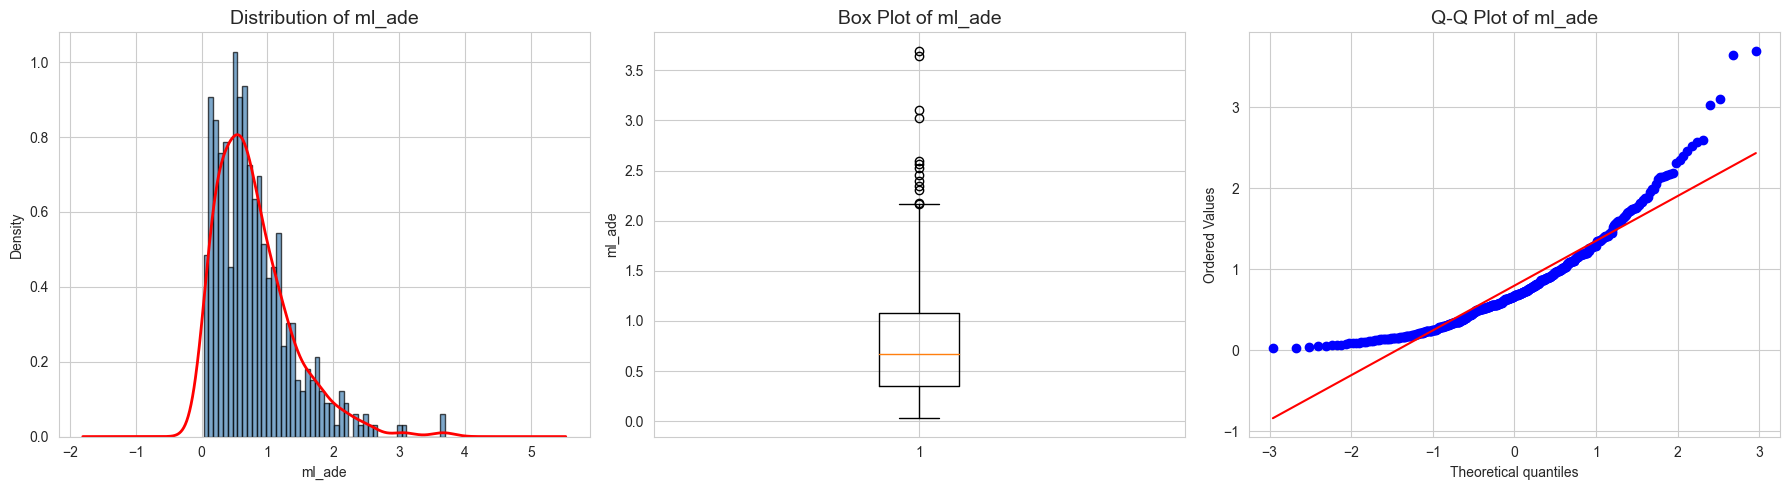


Target 'ml_ade' statistics:
  Skewness:  1.4600
  Kurtosis:  3.1145
  → Target is RIGHT-SKEWED (skewness > 1). Log transformation recommended.
    (Common for ADE/FDE — error distributions are typically right-skewed)


In [6]:
# Distribution of the target variable (prediction error metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
axes[0].hist(df[target_col].dropna(), bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="black")
df[target_col].dropna().plot.kde(ax=axes[0], color="red", linewidth=2)
axes[0].set_title(f"Distribution of {target_col}", fontsize=14)
axes[0].set_xlabel(target_col)
axes[0].set_ylabel("Density")

# Box plot
axes[1].boxplot(df[target_col].dropna(), vert=True)
axes[1].set_title(f"Box Plot of {target_col}", fontsize=14)
axes[1].set_ylabel(target_col)

# Q-Q plot
stats.probplot(df[target_col].dropna(), dist="norm", plot=axes[2])
axes[2].set_title(f"Q-Q Plot of {target_col}", fontsize=14)

plt.tight_layout()
plt.savefig(SAVE_DIR / f"target_distribution_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

# Skewness and kurtosis
target_skewness = skew(df[target_col].dropna())
target_kurtosis = stats.kurtosis(df[target_col].dropna())
print(f"\nTarget '{target_col}' statistics:")
print(f"  Skewness:  {target_skewness:.4f}")
print(f"  Kurtosis:  {target_kurtosis:.4f}")

if target_skewness > 1:
    print(f"  → Target is RIGHT-SKEWED (skewness > 1). Log transformation recommended.")
    print(f"    (Common for ADE/FDE — error distributions are typically right-skewed)")
elif target_skewness > 0.5:
    print(f"  → Target is MODERATELY right-skewed.")
else:
    print(f"  → Target is approximately symmetric.")

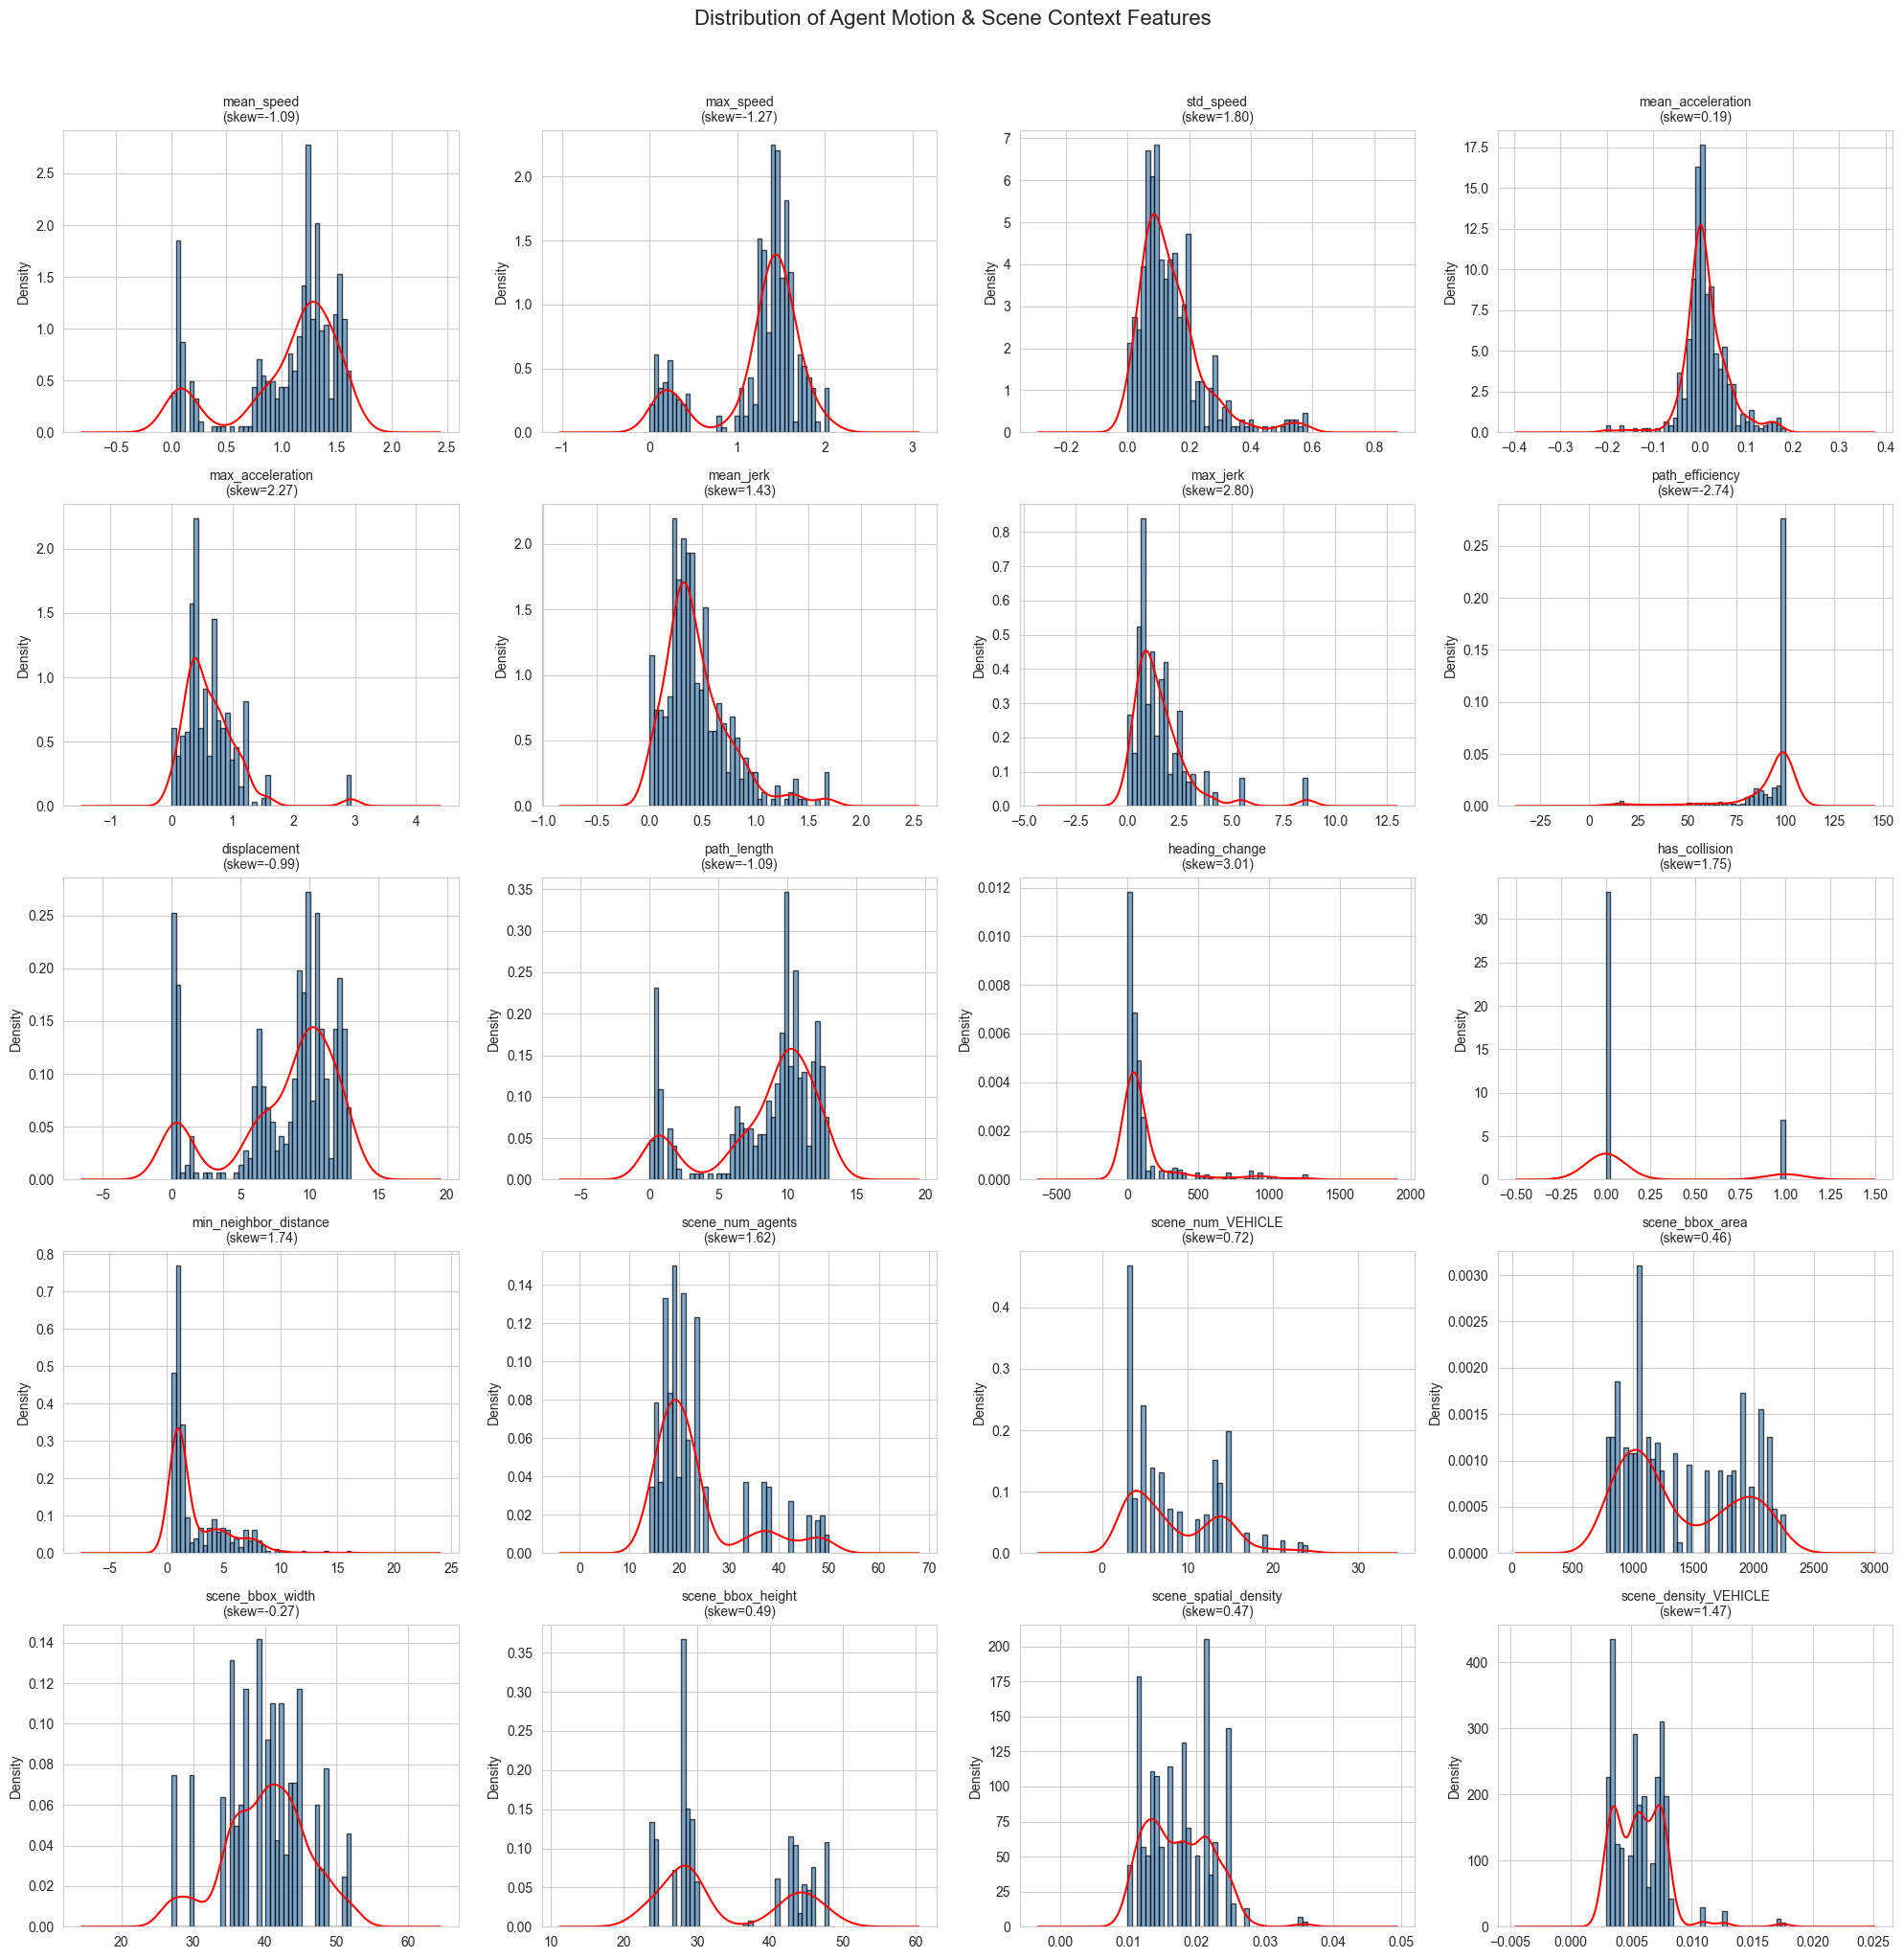

In [7]:
# Distribution of all numerical features
n_features = len(numerical_cols)
n_cols_plot = 4
n_rows_plot = int(np.ceil(n_features / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten() if n_features > 1 else [axes]

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=40, density=True, alpha=0.7, color="steelblue", edgecolor="black")
    df[col].dropna().plot.kde(ax=axes[i], color="red", linewidth=1.5)
    col_skew = skew(df[col].dropna())
    axes[i].set_title(f"{col}\n(skew={col_skew:.2f})", fontsize=10)
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Agent Motion & Scene Context Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Skewness summary table for all features and the target
skewness_df = pd.DataFrame({
    "Feature": numerical_cols + [target_col],
    "Skewness": [skew(df[c].dropna()) for c in numerical_cols + [target_col]],
    "Kurtosis": [stats.kurtosis(df[c].dropna()) for c in numerical_cols + [target_col]]
})
skewness_df["Skew Category"] = skewness_df["Skewness"].apply(
    lambda x: "Right-skewed" if x > 1 else ("Moderate" if x > 0.5 else ("Left-skewed" if x < -1 else "Symmetric"))
)
skewness_df = skewness_df.sort_values("Skewness", ascending=False).reset_index(drop=True)
print("Skewness Summary:")
skewness_df

Skewness Summary:


,Feature,Skewness,Kurtosis,Skew Category
0,heading_change,3.013466,8.802533,Right-skewed
1,max_jerk,2.798622,10.532398,Right-skewed
2,max_acceleration,2.272278,8.602435,Right-skewed
3,std_speed,1.803465,4.263631,Right-skewed
4,has_collision,1.750150,1.063025,Right-skewed
5,min_neighbor_distance,1.737306,3.199607,Right-skewed
6,scene_num_agents,1.619830,1.586252,Right-skewed
7,scene_density_VEHICLE,1.467618,5.765297,Right-skewed
8,ml_ade,1.460047,3.114523,Right-skewed
9,mean_jerk,1.429759,2.699040,Right-skewed


## 4. Correlation Analysis (Linear and Non-Linear)

Compute Pearson (linear) and Spearman (non-linear monotonic) correlations between agent motion features, scene context features, and the prediction error target. Mutual information scores detect arbitrary non-linear dependencies.

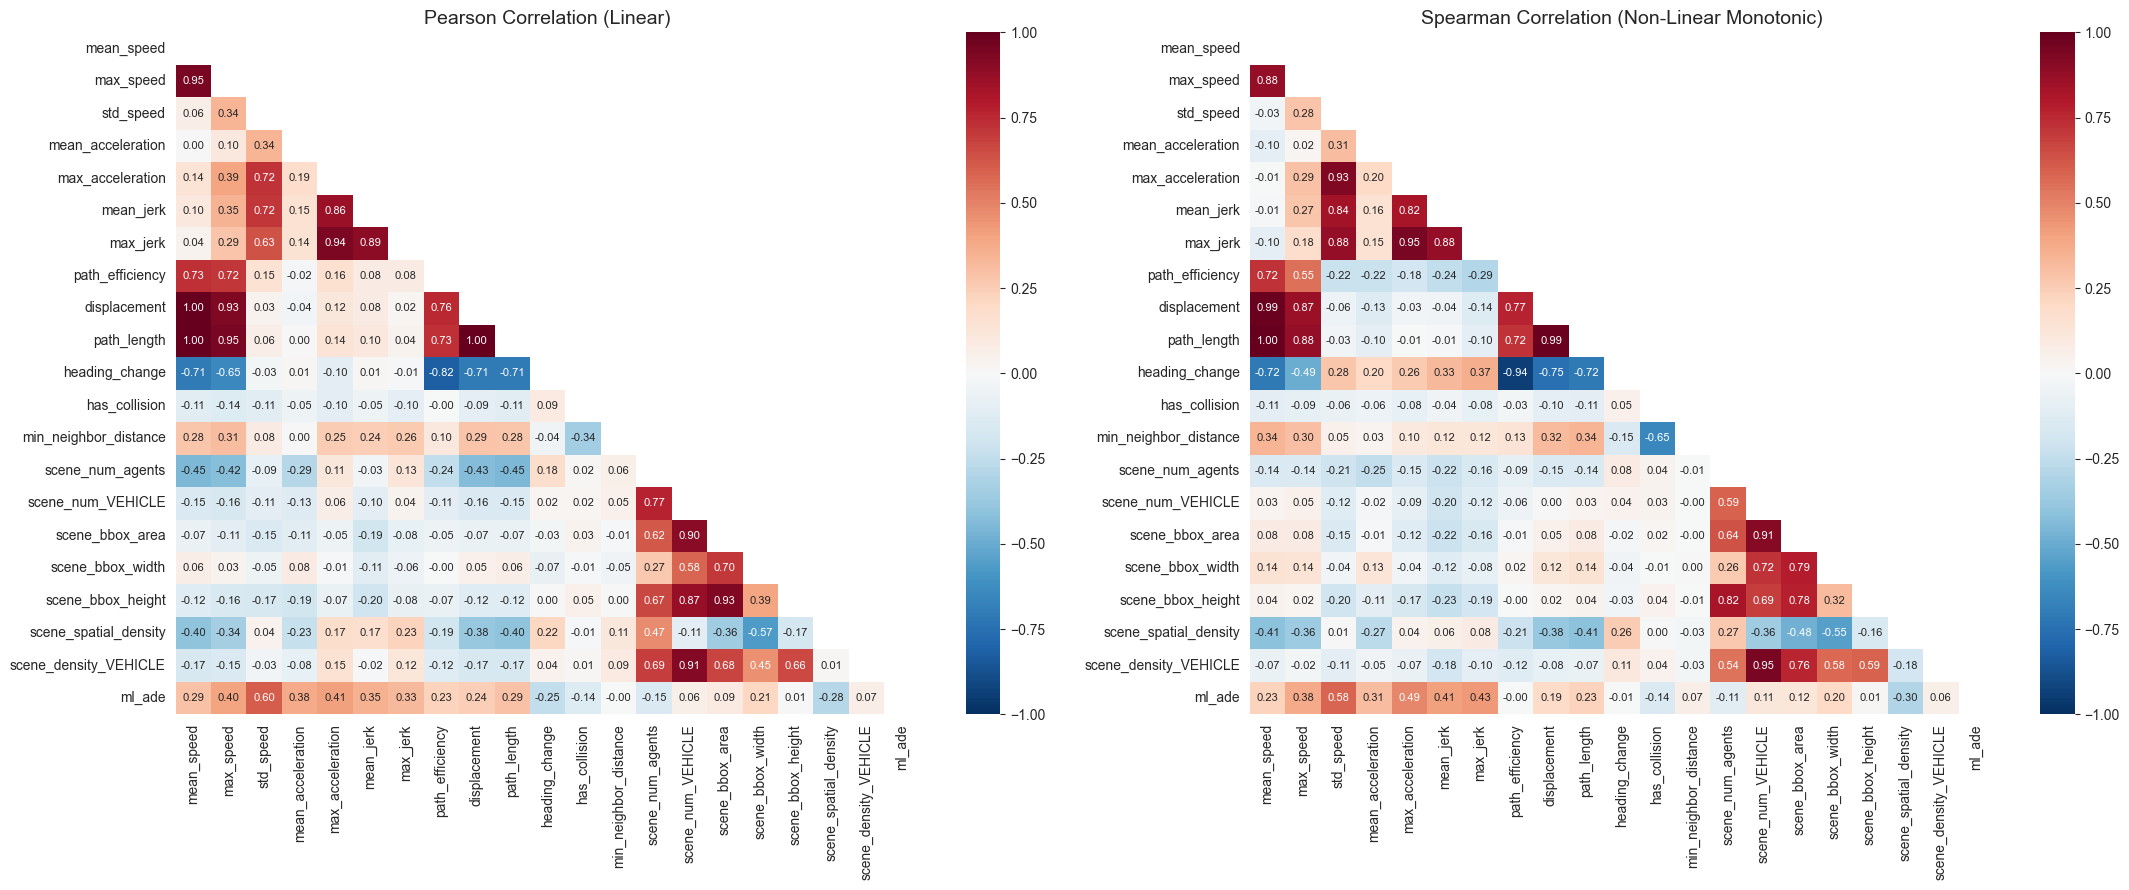

In [9]:
# Pearson and Spearman correlation matrices
all_numeric = numerical_cols + [target_col]
pearson_corr = df[all_numeric].corr(method="pearson")
spearman_corr = df[all_numeric].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Pearson heatmap
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[0], annot_kws={"size": 8})
axes[0].set_title("Pearson Correlation (Linear)", fontsize=14)

# Spearman heatmap
mask2 = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask2, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Spearman Correlation (Non-Linear Monotonic)", fontsize=14)

plt.tight_layout()
plt.savefig(SAVE_DIR / "correlation_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Compare Pearson vs Spearman correlations with the target
corr_comparison = pd.DataFrame({
    "Feature": numerical_cols,
    "Pearson (with target)": [pearson_corr.loc[c, target_col] for c in numerical_cols],
    "Spearman (with target)": [spearman_corr.loc[c, target_col] for c in numerical_cols],
})
corr_comparison["Difference (|P - S|)"] = abs(
    corr_comparison["Pearson (with target)"] - corr_comparison["Spearman (with target)"]
)
corr_comparison = corr_comparison.sort_values("Pearson (with target)", ascending=False, key=abs).reset_index(drop=True)

print("Pearson vs Spearman Correlation with Target:")
print("(Large differences suggest non-linear relationships)")
corr_comparison

Pearson vs Spearman Correlation with Target:
(Large differences suggest non-linear relationships)


,Feature,Pearson (with target),Spearman (with target),Difference (|P - S|)
0,std_speed,0.604552,0.578428,0.026124
1,max_acceleration,0.408524,0.492077,0.083553
2,max_speed,0.404844,0.377828,0.027016
3,mean_acceleration,0.379868,0.305757,0.074111
4,mean_jerk,0.352247,0.409452,0.057205
5,max_jerk,0.326687,0.433106,0.106419
6,mean_speed,0.292345,0.232928,0.059417
7,path_length,0.292345,0.232929,0.059416
8,scene_spatial_density,-0.284785,-0.302386,0.017601
9,heading_change,-0.246151,-0.005637,0.240514


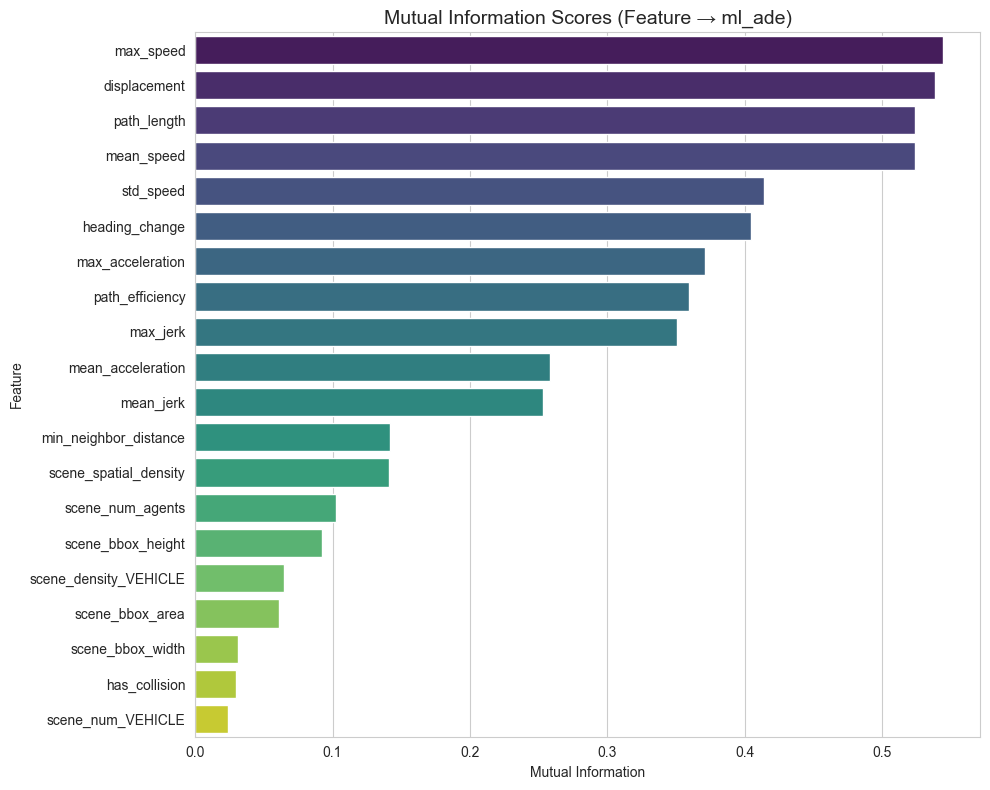

,Feature,Mutual Information
0,max_speed,0.544170
1,displacement,0.538797
2,path_length,0.524372
3,mean_speed,0.524242
4,std_speed,0.413781
5,heading_change,0.405001
6,max_acceleration,0.371108
7,path_efficiency,0.359630
8,max_jerk,0.350978
9,mean_acceleration,0.258314


In [11]:
# Mutual Information scores (detects non-linear dependencies)
X_for_mi = df[numerical_cols].dropna()
y_for_mi = df.loc[X_for_mi.index, target_col]

mi_scores = mutual_info_regression(X_for_mi, y_for_mi, random_state=42)
mi_df = pd.DataFrame({
    "Feature": numerical_cols,
    "Mutual Information": mi_scores
}).sort_values("Mutual Information", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(numerical_cols) * 0.4)))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis", ax=ax)
ax.set_title(f"Mutual Information Scores (Feature → {target_col})", fontsize=14)
plt.tight_layout()
plt.savefig(SAVE_DIR / "mutual_information_scores.png", dpi=150, bbox_inches="tight")
plt.show()

mi_df

## 5. Remove Highly Correlated Features

Identify pairs of features with absolute correlation above a threshold (e.g., 0.85). Remove one feature from each pair, keeping the one more correlated with the prediction error target.

In [12]:
def remove_highly_correlated(df, feature_cols, target_col, threshold=0.85):
    """
    Remove one feature from each pair of highly correlated features,
    keeping the one with higher absolute correlation with the target.
    
    Returns:
        selected_features: list of features to keep
        removed_features: list of removed features with reasons
    """
    corr_matrix = df[feature_cols].corr(method="pearson").abs()
    target_corr = df[feature_cols].corrwith(df[target_col]).abs()
    
    removed = set()
    removal_log = []
    
    for i in range(len(feature_cols)):
        for j in range(i + 1, len(feature_cols)):
            feat_i = feature_cols[i]
            feat_j = feature_cols[j]
            
            if feat_i in removed or feat_j in removed:
                continue
                
            if corr_matrix.loc[feat_i, feat_j] >= threshold:
                if target_corr[feat_i] >= target_corr[feat_j]:
                    removed.add(feat_j)
                    removal_log.append({
                        "Removed": feat_j,
                        "Kept": feat_i,
                        "Inter-correlation": corr_matrix.loc[feat_i, feat_j],
                        f"Corr with {target_col} (removed)": target_corr[feat_j],
                        f"Corr with {target_col} (kept)": target_corr[feat_i],
                    })
                else:
                    removed.add(feat_i)
                    removal_log.append({
                        "Removed": feat_i,
                        "Kept": feat_j,
                        "Inter-correlation": corr_matrix.loc[feat_i, feat_j],
                        f"Corr with {target_col} (removed)": target_corr[feat_i],
                        f"Corr with {target_col} (kept)": target_corr[feat_j],
                    })
    
    selected_features = [f for f in feature_cols if f not in removed]
    return selected_features, removal_log


# Apply correlation-based feature removal
CORR_THRESHOLD = 0.85
selected_features, removal_log = remove_highly_correlated(
    df, numerical_cols, target_col, threshold=CORR_THRESHOLD
)

print(f"Correlation threshold: {CORR_THRESHOLD}")
print(f"Original features: {len(numerical_cols)}")
print(f"Features after removal: {len(selected_features)}")
print(f"Features removed: {len(numerical_cols) - len(selected_features)}")

if removal_log:
    print(f"\nRemoval details:")
    removal_df = pd.DataFrame(removal_log)
    display(removal_df)
else:
    print("\nNo features exceeded the correlation threshold.")

print(f"\nSelected features: {selected_features}")

Correlation threshold: 0.85
Original features: 20
Features after removal: 13
Features removed: 7

Removal details:


,Removed,Kept,Inter-correlation,Corr with ml_ade (removed),Corr with ml_ade (kept)
0,mean_speed,max_speed,0.945788,0.292345,0.404844
1,displacement,max_speed,0.933267,0.243689,0.404844
2,path_length,max_speed,0.945788,0.292345,0.404844
3,mean_jerk,max_acceleration,0.860155,0.352247,0.408524
4,max_jerk,max_acceleration,0.944557,0.326687,0.408524
5,scene_num_VEHICLE,scene_bbox_area,0.903792,0.058121,0.088921
6,scene_bbox_height,scene_bbox_area,0.926792,0.006823,0.088921



Selected features: ['max_speed', 'std_speed', 'mean_acceleration', 'max_acceleration', 'path_efficiency', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_spatial_density', 'scene_density_VEHICLE']


## 6. Log Transform Target (If Right Skewed)

Trajectory prediction errors (ADE/FDE) are typically right-skewed. Apply `np.log1p()` transformation if skewness > 1. Compare distributions before and after.

Target skewness: 1.4600
Apply log transformation: True


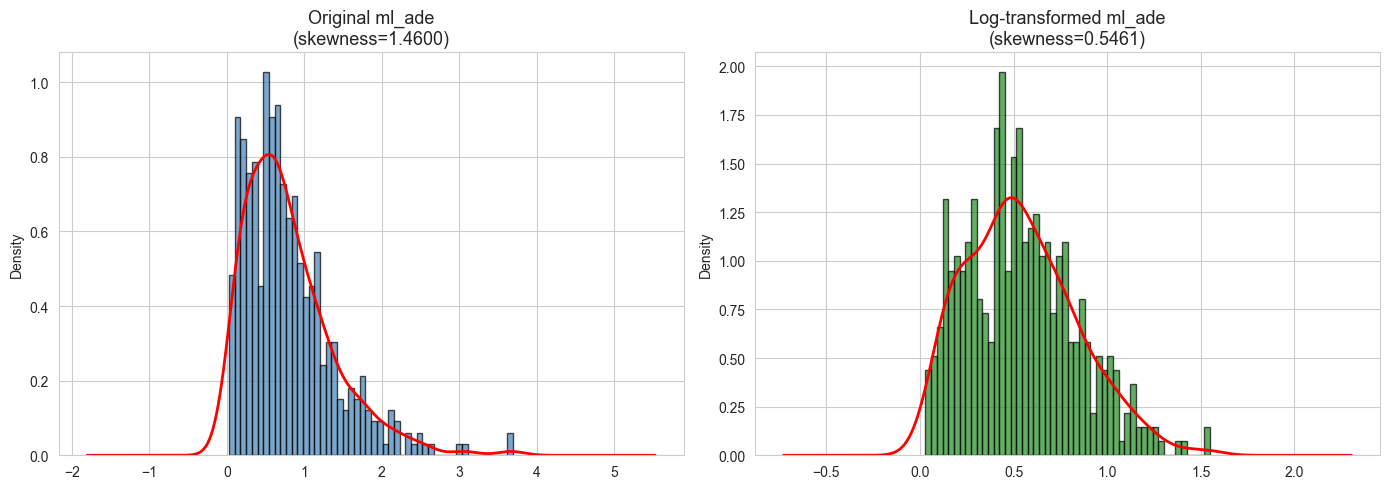


Log-transformed target column: 'ml_ade_log'


In [13]:
# Decide on log transformation
LOG_TRANSFORM = target_skewness > 1.0
print(f"Target skewness: {target_skewness:.4f}")
print(f"Apply log transformation: {LOG_TRANSFORM}")

if LOG_TRANSFORM:
    y_original = df[target_col].copy()
    # Use log1p for numerical stability (handles values near zero)
    df[f"{target_col}_log"] = np.log1p(df[target_col])
    y_transformed_col = f"{target_col}_log"
    
    # Plot before and after
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(y_original.dropna(), bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="black")
    y_original.dropna().plot.kde(ax=axes[0], color="red", linewidth=2)
    axes[0].set_title(f"Original {target_col}\n(skewness={skew(y_original.dropna()):.4f})", fontsize=13)
    
    y_log = df[y_transformed_col]
    axes[1].hist(y_log.dropna(), bins=50, density=True, alpha=0.7, color="forestgreen", edgecolor="black")
    y_log.dropna().plot.kde(ax=axes[1], color="red", linewidth=2)
    axes[1].set_title(f"Log-transformed {target_col}\n(skewness={skew(y_log.dropna()):.4f})", fontsize=13)
    
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"target_log_transform_{target_col}.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"\nLog-transformed target column: '{y_transformed_col}'")
else:
    y_transformed_col = target_col
    print("No transformation applied — target is approximately symmetric.")

In [14]:
# Prepare the data (drop rows with NaN in selected features or target)
model_df = df[selected_features + [y_transformed_col]].dropna().copy()
print(f"Rows available for modeling: {len(model_df)} (dropped {len(df) - len(model_df)} rows with NaN)")

X = model_df[selected_features].values
y = model_df[y_transformed_col].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Rows available for modeling: 451 (dropped 0 rows with NaN)

Feature matrix shape: (451, 13)
Target vector shape: (451,)


In [15]:
# Export prepared dataset into results/interpretable_model/prepared_data
EXPORT_DIR = Path("../../results/interpretable_model/prepared_data")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PATH = EXPORT_DIR / f"prepared_data_{target_col}.csv"
model_df.to_csv(EXPORT_PATH, index=False)
print(f"\nPrepared dataset exported to: {EXPORT_PATH}")


Prepared dataset exported to: ../../results/interpretable_model/prepared_data/prepared_data_ml_ade.csv
